In [1]:
import requests
import pandas as pd
import time
import re
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [2]:
def cefr_to_numeric(level: str) -> int:
    mapping = {"A1": 1, "A2": 2, "B1": 3, "B2": 4, "C1": 5, "C2": 6, "Не определен": "Не определен", "А1": 1,"А2": 2, "Б1": 3, "Б2": 4, "С1": 5, "С2": 6}
    return mapping.get(level, 0)


def numeric_to_cefr(value: int) -> str:
    mapping = {1: "A1", 2: "A2", 3: "B1", 4: "B2", 5: "C1", 6: "C2", "Не определен": "Не определен"}
    return mapping.get(value, "Не определен")

In [3]:
def extract_cefr_level(response: str) -> str:
    if not response:
        return "Ошибка"
    
    response_upper = response.upper().strip()
    levels = ["A1", "A2", "B1", "B2", "C1", "C2", "А1", "А2", "Б1", "Б2", "С1", "С2"]
    
    for level in levels:
        if level in response_upper:
            return level
    
    return "Не определен"

In [4]:
class RussianOllamaClient:
    def __init__(self, model_name="llama3"):
        self.model_name = model_name
        self.base_url = "http://localhost:11434"
        print(f"Используем модель: {model_name}")
    
    def make_request(self, prompt: str, max_tokens: int = 100, num_ctx: int = 8192) -> str:
        data = {
            "model": self.model_name,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": 0.3,
                "num_predict": max_tokens,
                "num_ctx": num_ctx, 
            }
        }
        
        try:
            response = requests.post(
                f"{self.base_url}/api/generate", 
                json=data, 
                timeout=120
            )
            
            if response.status_code == 200:
                result = response.json()
                return result['response']
            else:
                print(f"❌ Ошибка {response.status_code}")
                return ""
                
        except Exception as e:
            print(f"❌ Исключение: {e}")
            return ""

In [5]:
client = RussianOllamaClient("llama3:8b")  
    
test_response = client.make_request("Скажи 'тест пройден'")
if test_response:
    print("✅ Модель работает")
else:
    print("❌ Модель не отвечает")

Используем модель: llama3:8b
✅ Модель работает


In [6]:
df = pd.read_csv('ru_cefr_short.csv')
df

,fragment,textbook-assigned cefr level
0,"Весной, летом и осенью почти каждую субботу он...",1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1
2,На каждой двери красные плакаты и красные фона...,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1
...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6
7320,Mapillary использует программное обеспечение д...,6


In [7]:
X_train, X_test, y_train, y_test = train_test_split(df['fragment'], df['textbook-assigned cefr level'], test_size=0.2, random_state=42)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Обучающая выборка: 5857
Тестовая выборка: 1465


In [8]:
texts_to_test = X_test.tolist()
levels_to_test = y_test.tolist()

len(texts_to_test) == len(levels_to_test)

True

In [9]:
def create_few_shot_cot_prompt(text):
    return f'''Ты - эксперт по русскому языку как иностранному (РКИ). Определи уровень CEFR текста на основе комплексного анализа. 

Проведи анализ текста по следующим аспектам:

1. ЛЕКСИЧЕСКИЙ АНАЛИЗ:
   - Частотность и тематика лексики (повседневная/бытовая/абстрактная/специальная)
   - Наличие стилистически окрашенной лексики, фразеологизмов, идиом
   - Использование научной, деловой или публицистической лексики
   - Наличие устаревших, книжных или жаргонных слов

2. ГРАММАТИЧЕСКИЙ АНАЛИЗ:
   - Глаголы движения (с приставками/без приставок, виды пар)
   - Падежная система (простые/сложные падежные конструкции)
   - Причастия и деепричастия (наличие/отсутствие, обороты)
   - Формы пассива, безличные конструкции
   - Императивные формы, возвратные глаголы
   - Сравнительная и превосходная степень прилагательных
   - Собирательные числительные, неопределенные местоимения

3. СИНТАКСИЧЕСКИЙ АНАЛИЗ:
   - Длина и сложность предложений
   - Типы предложений (простые/сложные)
   - Используемые союзы и союзные слова (простые/сложные)
   - Наличие придаточных предложений разных типов
   - Использование деепричастных и причастных оборотов
   - Конструкции с инфинитивом в различных позициях
   - Особые синтаксические конструкции (условные, уступительные, целевые)

4. СТИЛИСТИЧЕСКИЙ АНАЛИЗ:
   - Стиль речи (разговорный/официальный/научный/художественный)
   - Степень номинализации
   - Логические связи между частями текста
   - Использование вводных слов и конструкций
   - Субъективные оценки, эмоциональная окраска

A1: Очень частотная повседневная лексика, простые предложения, базовые падежи. Глаголы движения без приставок (идти-ходить, ехать-ездить). Предложный падеж с предлогом о, дательный падеж (кому), родительный падеж (нет урока, тетрадь студента). Конструкции с предлогами из, для, без, около, после. Простые предложения или короткие сложноподчиненные с союзами что, потому что. Конструкции типа "мне холодно". Достижение уровня для удовлетворения элементарных коммуникативных потребностей.

A2: Частотная лексика, глаголы движения с приставками (по-, при-, в-, вы-, пере-, под-, до-, об-, за-) в прошедшем и будущем времени. Фразы с "ещё" и "уже", формы императива, простые случаи косвенной речи, возвратные глаголы и местоимения. Сложносочиненные предложения с союзами и, или, а, но. Короткие сложноподчиненные предложения с придаточными времени, условия, цели (когда, если, чтобы), предложения с союзным словом "который". Расширение сферы межличностного общения в стандартных ситуациях повседневной жизни.

B1: Абстрактная лексика, причастия/деепричастия, причастные и деепричастные обороты, формы пассива. Глаголы движения (бежать-бегать, лететь-летать и др.) с приставками. Собирательные числительные (двое), неопределенные местоимения (кто-то), сравнительная и превосходная степень прилагательных. Сложносочиненные предложения с союзами только, однако, либо. Сложноподчиненные предложения со словами там, туда, оттуда, из-за, благодаря, несмотря на, хотя, для того чтобы, в то время как, пока. Условные конструкции "если бы". Подготовка к обучению в вузах, поддержание социально-делового общения.

B2: Стилистически окрашенная лексика, лексика научного и официально-делового стиля, фразеология. Активно используются деепричастные обороты, страдательный залог, причастия, разнообразные союзы и предлоги, сложная структура предложений. Предложения с безличными глаголами (хочется), нетипичные случаи выражения субъекта и предиката, инфинитив в позиции подлежащего. Конструкции с выражением субъективной оценки: частицы пусть, конструкции с должен, вынужден. Конструкции с наречиями негде, некогда, предложения с предлогами при, вместо, ради. Обучение в вузе, использование различных стилей языка, свободное понимание СМИ.

C1: Сложная лексика, длинные предложения с придаточными, высокая степень номинализации, возможна устаревшая или книжная лексика. Всё многообразие типов придаточных предложений. Длинные предложения с несколькими придаточными и сложными союзами: как вдруг, в то время как, после того как, с тех пор как, благодаря тому что, вследствие того что, поскольку, так что, с тем чтобы, будто, словно. Предложения с предикатным, присловным и противопоставительным отрицанием. Неопределённо-личные и безличные конструкции. Владение различными стилями языка, способность воспринимать информацию во всей полноте в различных ситуациях общения.

C2: Научный стиль, идиомы, сложные синтаксические конструкции. Синтаксические модели выражения логической связи: что является чем, представляет собой, относится к, предназначено для, обозначается как, ведет к чему, состоит из чего, из чего следует что, характеризуется чем. Устойчивые обороты речи, идиомы. Владение языком на профессиональном уровне, включая преподавание РКИ и научно-исследовательскую работу.

Текст для анализа: "Я живу в маленьком городе"
Уровень CEFR: A1

Текст для анализа: "Летом в деревне мне нравится купаться и делать что-нибудь в саду"
Уровень CEFR: A2

Текст для анализа: "В прошлом году мы ездили в Сочи, где каждый день купались в море и ели вкусные фрукты"
Уровень CEFR: A2

Текст для анализа: "Когда я впервые приехал в Москву, меня удивило, как быстро здесь меняется погода"
Уровень CEFR: B1

Текст для анализа: "Гуляя по Москве, мы наткнулись на маленький зеленый дворик, притаившийся за главной улицей"
Уровень CEFR: B1

Текст для анализа: "Несмотря на дождливую погоду, наш концерт под открытым небом не просто состоялся, а прогремел: мы собрали толпу преданных слушателей, подпевавших нам на все лады"
Уровень CEFR: B2

Текст для анализа: "Хотя статистические данные указывают на спад интереса к чтению, в некоторых регионах можно наблюдать обратную тенденцию, обусловленную развитием местных библиотечных инициатив"
Уровень CEFR: C1

Текст для анализа: "Покачиваясь вместе с вагоном, мы преодолевали бескрайние просторы Сибири, и, чем дальше мы уезжали от столиц и больших городов, тем чаще ловили себя на мысли, что сама протяжённость этого пути, постоянная смена пейзажа и наших попутчиков, становится самоцелью путешествия, расстояния измеряются здесь уже не километрами, а прожитыми мгновениями: как пелось в той песне, “есть только миг”"
Уровень CEFR: C2

АЛГОРИТМ АНАЛИЗА (пройди мысленно каждый шаг):

1. Прочитай текст внимательно и определи общее впечатление о сложности
2. Проанализируй лексику по критериям выше
3. Проанализируй грамматические особенности
4. Проанализируй синтаксическую структуру
5. Определи стилистические характеристики
6. Сравни с примерами для каждого уровня
7. Сопоставь с контекстными критериями
8. Определи наиболее соответствующий уровень

Текст для анализа: "{text}"

Верни ТОЛЬКО уровень CEFR (A1, A2, B1, B2, C1, C2) без дополнительных объяснений.
'''

In [10]:
model_responses = []
predicted_levels = []

print(f"Анализируем {len(texts_to_test)} текстов...")

for i in range(len(texts_to_test)):
    text, real_level = texts_to_test[i], levels_to_test[i]
    
    print(f"\nТекст {i+1}/{len(X_test)}: {text[:80]}...")
    
    prompt = create_few_shot_cot_prompt(text)
    response = client.make_request(prompt)
    level = extract_cefr_level(response)
    
    print(f"    Реальный уровень {numeric_to_cefr(real_level)}")
    print(f"    Предсказание модели: {level}")

    predicted_levels.append(cefr_to_numeric(level))
    model_responses.append(response)

Анализируем 1465 текстов...

Текст 1/1465: Организм после бани легче переносит физические нагрузки, интенсивную работу, луч...
    Реальный уровень B1
    Предсказание модели: B1

Текст 2/1465: Через полстолетия в моду входит не просто стройность, а настоящая худоба. В шест...
    Реальный уровень A2
    Предсказание модели: B1

Текст 3/1465: Одного беглого взгляда на кривую саврасовскую берёзку хватит, чтобы вспомнить ур...
    Реальный уровень B2
    Предсказание модели: B1

Текст 4/1465: С развитием науки в МГУ открывались новые и новые факультеты, например, факульте...
    Реальный уровень B1
    Предсказание модели: Не определен

Текст 5/1465: Обычно первые числа мая объявляются нерабочими, поэтому люди гуляют по городу ил...
    Реальный уровень B2
    Предсказание модели: A2

Текст 6/1465: «Проекты о путешествиях Познера и Урганта», Первый канал. Первая совместная рабо...
    Реальный уровень B1
    Предсказание модели: B2

Текст 7/1465: Телевидение вошло в наши дома очень скром

In [11]:
df_pred = pd.DataFrame(columns=['text', 'real_level', 'predicted_level', 'model_response'])
df_pred['text'] = texts_to_test
df_pred['real_level'] = levels_to_test
df_pred['predicted_level'] = predicted_levels
df_pred['model_response'] = model_responses
df_pred

,text,real_level,predicted_level,model_response
0,Организм после бани легче переносит физические...,3,3,"Based on the analysis of the text, I would det..."
1,Через полстолетия в моду входит не просто стро...,2,3,"Based on the analysis of the text, I would det..."
2,Одного беглого взгляда на кривую саврасовскую ...,4,3,"After analyzing the text, I would determine it..."
3,С развитием науки в МГУ открывались новые и но...,3,Не определен,Based on the algorithm analysis:\n\n1. General...
4,Обычно первые числа мая объявляются нерабочими...,4,2,"Based on the analysis of the text, I determine..."
...,...,...,...,...
1460,"Лишний вес не только вреден для здоровья, но и...",4,3,"After analyzing the text, I would determine th..."
1461,"Русские люди встречают Новый год ночью, в 12 ч...",1,3,"Based on the analysis of the text, I determine..."
1462,Во второй раз можно париться уже на верхней по...,3,Не определен,Based on the algorithm analysis:\n\n1. Initial...
1463,Несмотря на то что многие годы павловопосадски...,4,3,"Based on the analysis of the text, I would det..."


In [12]:
df_pred.to_csv("few-shot-cot.csv", index=False)

In [13]:
df_pred['predicted_level'].unique()

array([3, 'Не определен', 2, 4, 1, 5, 6], dtype=object)

In [14]:
df_pred[df_pred['predicted_level'] == 'Не определен']

,text,real_level,predicted_level,model_response
3,С развитием науки в МГУ открывались новые и но...,3,Не определен,Based on the algorithm analysis:\n\n1. General...
9,"Сегодня эти изделия популярны, как и прежде. С...",4,Не определен,Based on the algorithm analysis:\n\n1. General...
21,"Согласно исследованиям, алкоголь является одни...",4,Не определен,Based on the algorithm analysis:\n\n1. Overall...
26,Певица Селин Дион ездит в магазины на «роллсро...,2,Не определен,Based on the algorithm analysis:\n\n1. The tex...
27,"«У него есть семья, есть дорогие ему люди, и м...",3,Не определен,Based on the algorithm analysis:\n\n1. The tex...
...,...,...,...,...
1454,"Человек, знающий с детства или долгие годы о с...",3,Не определен,Based on the algorithm analysis:\n\n1. The tex...
1455,"Раньше дети часто работали, а в наше время они...",1,Не определен,Based on the algorithm analysis:\n\n1. The tex...
1458,"В субботу Мария, Клара, Том были на экскурсии ...",1,Не определен,Based on the algorithm analysis:\n\n1. The tex...
1459,Только в 1988 году роман «Доктор Живаго» был в...,3,Не определен,Based on the algorithm analysis:\n\n1. I read ...


In [15]:
df_eval = df_pred[
    df_pred['predicted_level'].notna() &
    (df_pred['predicted_level'] != 'Не определен')
].copy()

y_true = df_eval['real_level'].tolist()
y_pred = df_eval['predicted_level'].tolist()

print(f"Точность: {accuracy_score(y_true, y_pred):.4f}")

print(f"F1-score micro: {f1_score(y_true, y_pred, average='micro',  zero_division=0):.4f}")
print(f"F1-score macro: {f1_score(y_true, y_pred, average='macro',  zero_division=0):.4f}")
print(f"F1-score weighted: {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")

print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f}")

Точность: 0.3033
F1-score micro: 0.3033
F1-score macro: 0.1861
F1-score weighted: 0.2395
MAE: 1.0323


In [16]:
print(f"{accuracy_score(y_true, y_pred):.4f}")

print(f"{f1_score(y_true, y_pred, average='micro',  zero_division=0):.4f}")
print(f"{f1_score(y_true, y_pred, average='macro',  zero_division=0):.4f}")
print(f"{f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")

print(f"{mean_absolute_error(y_true, y_pred):.4f}")

0.3033
0.3033
0.1861
0.2395
1.0323


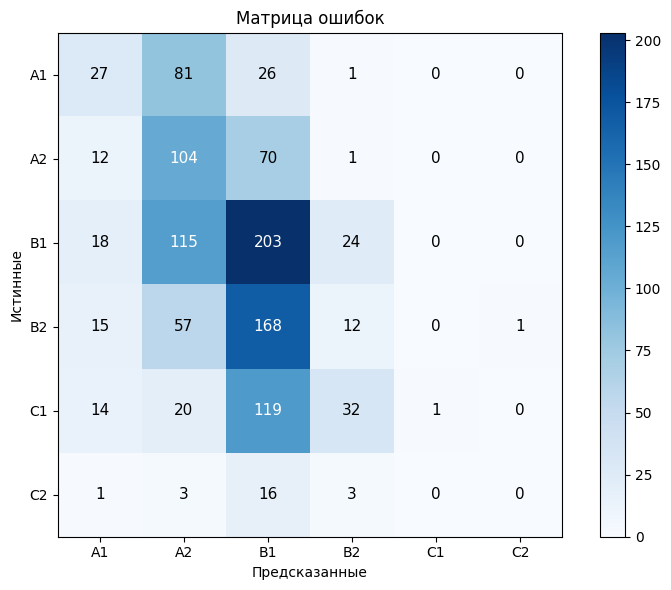

In [17]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        ax.text(
            j, i,
            f"{value:.0f}",
            ha="center",
            va="center",
            color="white" if value > cm.max() / 2 else "black",
            fontsize=11
        )

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')

plt.colorbar(im)
plt.tight_layout()
plt.show()